# Mixed layer depth in ACCESS models and observations

Related issue: https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38

Requires access to `/g/data/av17`

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"

# What physical field you want, in CF terms (stays the same across models)
variable_standard_name = "Ocean Mixed Layer Thickness Defined by Sigma T"

# Fallback variable name to use if the catalog doesn’t expose standard_name
fallback_variable_names = ["mlotst", "mld", "mixed_layer_depth", "mixed_layer_thickness"]

# Frequency depends on the datastore you’re using:
data_frequency = "1mon"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
if not papermill: 
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
from mkfigs_configdoc import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)
from exptdata_access import get_experiment_info, guess_experiment_from_esm_file
from model_agnostic import get_lon_lat_from_catalog, select_variable
# Infer model information from the datastore path
expt_key, info = guess_experiment_from_esm_file(esm_file)
model_name = info["model"]             # OM3 or CM3

In [3]:
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import cftime
import os
import matplotlib.pyplot as plt
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
from textwrap import wrap
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default

In [4]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38269,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41057,Total threads: 1
Dashboard: /proxy/43315/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:37597,


### Define plot function

In [5]:
blue_marble = plt.imread('/g/data/ik11/grids/BlueMarble.tiff')
blue_marble_extent = (-180, 180, -90, 90)

In [6]:
def plot(dat, title=None, **kwargs):
    if title is None:
        title = dat.attrs['long_name']
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100))
    dat.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={"label": "\n".join(wrap(f"{dat.attrs['long_name']} [{dat.attrs['units']}]", 45)),
                     "fraction": 0.03, "aspect": 15, "shrink": 0.7},
        **kwargs
    )
    
    # Add blue marble land:
    ax.imshow(
        blue_marble, extent=blue_marble_extent, transform=ccrs.PlateCarree(), origin="upper"
    )
    
    plt.title(title);

In [7]:
def seasonal_mean(da, months):
    # Select months, then do time-weighted mean
    da_m = da.where(da["time"].dt.month.isin(months), drop=True)
    w_m  = w.where(da["time"].dt.month.isin(months), drop=True)
    return da_m.weighted(w_m).mean("time")

### Load and plot data from ACCESS-OM3

In [8]:
exptname=os.path.basename(os.path.dirname(esm_file))
print("Experiment name:", exptname)

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
    ]
)

Experiment name: MC_25km_jra_iaf+wombatlite-test3v2-00532b88


In [9]:
da_model = select_variable(
    datastore,
    variable_standard_name,
    fallback_variable_names,
    data_frequency=data_frequency,
)
print("Selected variable:", da_model.name)
print("dims:", da_model.dims)

CF-based lookup failed: ValueError('No entries found for this CF standard_name.')
Selected variable via fallback name: mlotst
Selected variable: mlotst
dims: ('time', 'yh', 'xh')


In [10]:
# Discover lon/lat from the catalog (using the helper we wrote earlier)
lon, lat = get_lon_lat_from_catalog(datastore)

# Ensure model_all has CF longitude/latitude coords
try:
    # If CF coords already exist, just use them
    _ = da_model.cf["longitude"]
    _ = da_model.cf["latitude"]
    model_all = da_model
    print("Using existing CF longitude/latitude on da_model.")
except KeyError:
    # Otherwise, attach the lon/lat we discovered
    model_all = da_model.cf.assign_coords(
        {
            "longitude": lon,
            "latitude": lat,
        }
    )
    print("Attached longitude/latitude from catalog grid variables.")

print("model_all dims:", model_all.dims)

Using existing CF longitude/latitude on da_model.
model_all dims: ('time', 'yh', 'xh')


In [11]:
averaging_mode = "last_n_years"   # or "full_period" / "fixed_period"
averaging_last_n_years = 10
averaging_start_date = None
averaging_end_date   = None

In [12]:
if exptname == "25km-iaf-test-for-AK-expt-7df5ef4c":
    model_all = model_all.isel(yh=slice(10, None))
    lon = lon.isel(yh=slice(10, None))
    lat = lat.isel(yh=slice(10, None))

In [13]:
# Put model time axis on a common calendar
model_all = model_all.convert_calendar("proleptic_gregorian", use_cftime=True)

# Inspect full time coverage
t0 = model_all.time.values[0]
t1 = model_all.time.values[-1]
print("Full model time range:", t0, "→", t1)

# Decide the averaging window based on configuration
if averaging_mode == "full_period":
    datestart = t0
    datestop = t1

elif averaging_mode == "last_n_years":
    datestop = t1
    # Subtract N years in a calendar-aware way
    datelist = list(cftime.to_tuple(datestop))
    datelist[0] -= averaging_last_n_years
    datestart = cftime.datetime(*datelist, calendar=datestop.calendar)

elif averaging_mode == "fixed_period":
    if averaging_start_date is None or averaging_end_date is None:
        raise ValueError(
            "averaging_mode='fixed_period' requires averaging_start_date and averaging_end_date"
        )
    # Use cftime to create start/end on the same calendar
    datestart = xr.cftime_range(
        start=averaging_start_date,
        periods=1,
        calendar="proleptic_gregorian",
    )[0]
    datestop = xr.cftime_range(
        start=averaging_end_date,
        periods=1,
        calendar="proleptic_gregorian",
    )[0]
else:
    raise ValueError(f"Unknown averaging_mode: {averaging_mode!r}")

timerange = slice(datestart, datestop)
print("Averaging window:", timerange)

# Restrict model to this configured window
model_window = model_all.cf.sel(time=timerange)
print("Windowed dims:", model_window.dims)

Full model time range: 1958-01-16 12:00:00 → 2023-12-16 12:00:00
Averaging window: slice(cftime.datetime(2013, 12, 16, 12, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.DatetimeProlepticGregorian(2023, 12, 16, 12, 0, 0, 0, has_year_zero=True), None)
Windowed dims: ('time', 'yh', 'xh')


In [14]:
# weights = days in each timestep's month
w = model_window["time"].dt.days_in_month

In [15]:
%%time
model_JFM_mean = seasonal_mean(model_window, [1, 2, 3]).compute()
model_JAS_mean = seasonal_mean(model_window, [7, 8, 9]).compute()

CPU times: user 10.7 s, sys: 5.69 s, total: 16.4 s
Wall time: 15.7 s


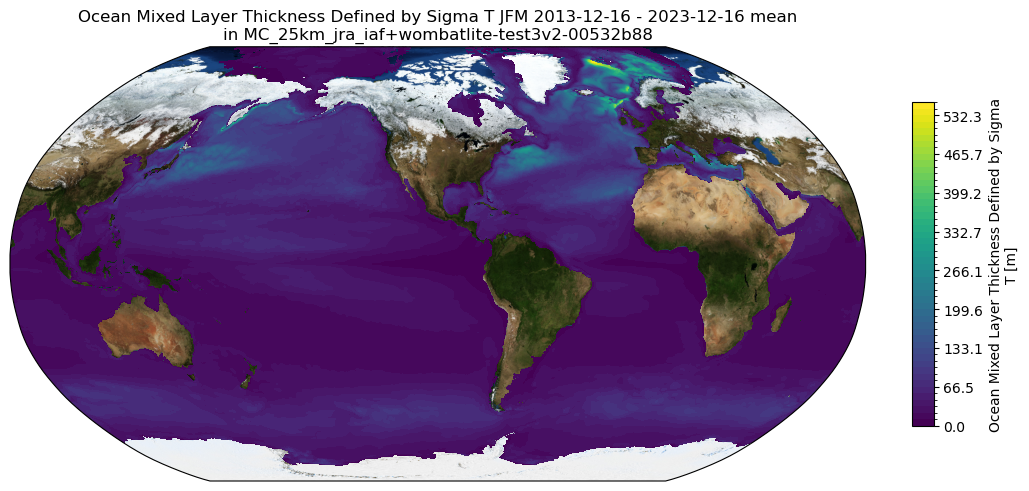

In [16]:
plot(model_JFM_mean,
    levels=51,
    vmin=0,
    vmax=None,
    cmap='viridis',
    title=f"{model_window.attrs['long_name']} JFM {model_window.time.values[0].strftime('%Y-%m-%d')} - {model_window.time.values[-1].strftime('%Y-%m-%d')} mean\nin {exptname}"
    )

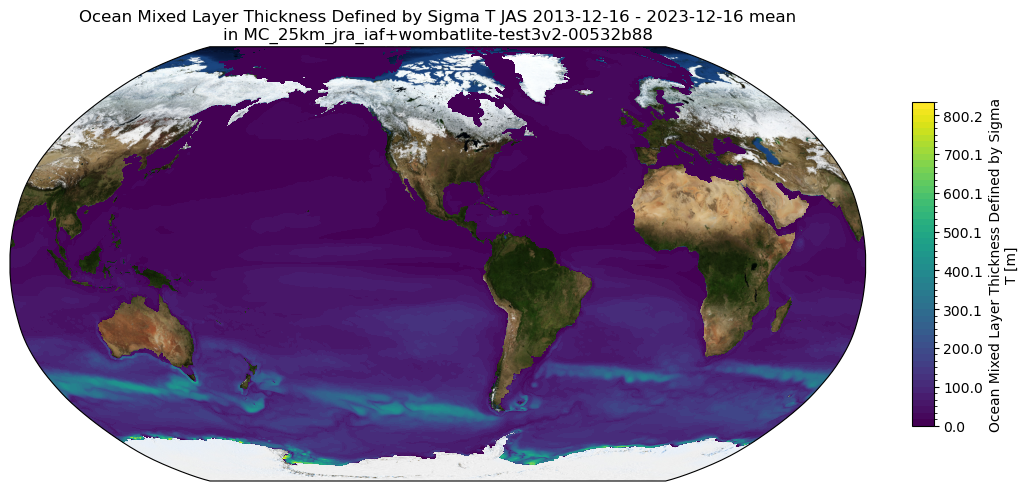

In [17]:
plot(model_JAS_mean,
    levels=51,
    vmin=0,
    vmax=None,
    cmap='viridis',
    title=f"{model_window.attrs['long_name']} JAS {model_window.time.values[0].strftime('%Y-%m-%d')} - {model_window.time.values[-1].strftime('%Y-%m-%d')} mean\nin {exptname}"
    )

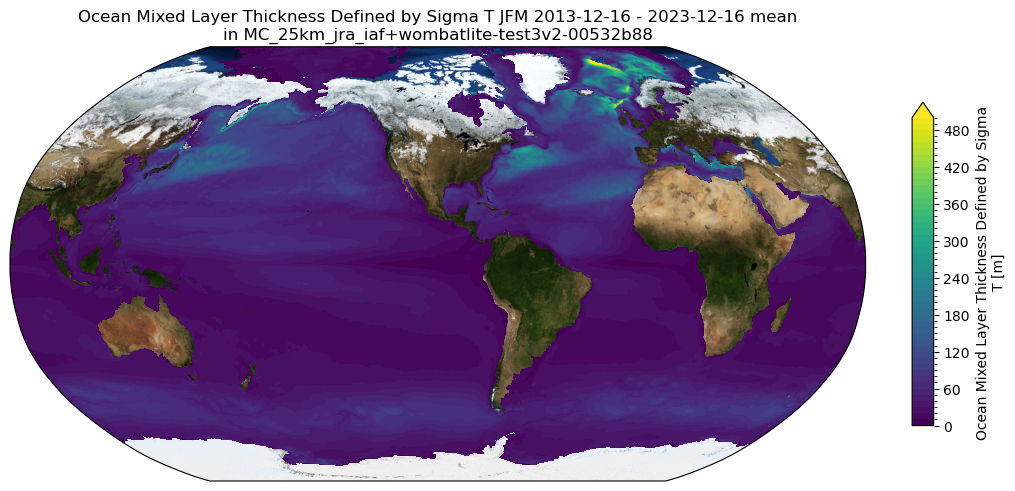

In [18]:
plot(model_JFM_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title=f"{model_window.attrs['long_name']} JFM {model_window.time.values[0].strftime('%Y-%m-%d')} - {model_window.time.values[-1].strftime('%Y-%m-%d')} mean\nin {exptname}"
    )
mkmd.savefig(plt.gcf(), "Mixed Layer Depth", "Ocean Mixed Layer Depth JFM.")

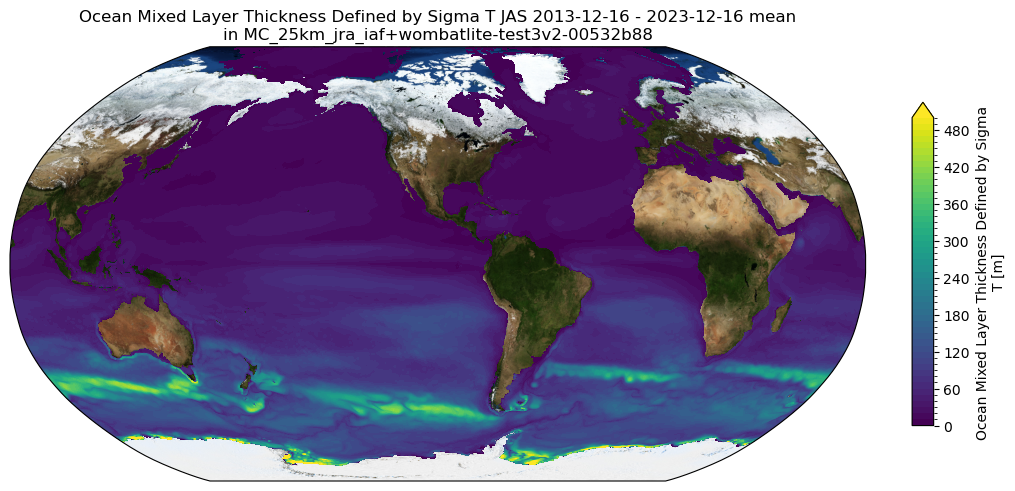

In [19]:
plot(model_JAS_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title=f"{model_window.attrs['long_name']} JAS {model_window.time.values[0].strftime('%Y-%m-%d')} - {model_window.time.values[-1].strftime('%Y-%m-%d')} mean\nin {exptname}"
    )
mkmd.savefig(plt.gcf(), "Mixed Layer Depth", "Ocean Mixed Layer Depth JAS.")

### Load and plot obs data from DeBoyer Montegut (2023)
https://doi.org/10.17882/91774

In [20]:
MLDobs = xr.open_dataset('/g/data/av17/access-nri/OM3/MLD-DeBoyerMontegut2023/mld_dr003_ref10m_v2023.nc')['mld_dr003']
MLDobs.attrs['units'] = MLDobs.attrs['unit']  # fix so plot works

# TODO: append copy of westernmost data to eastern end to avoid gap in plot

In [21]:
# small BUG: mean of monthly means is not mean of days in that month (eg Feb gets slightly more heavily weighted)
MLDobs_JFM_mean = MLDobs.isel(time=[0, 1, 2]).mean('time').load()
MLDobs_JAS_mean = MLDobs.isel(time=[6, 7, 8]).mean('time').load()

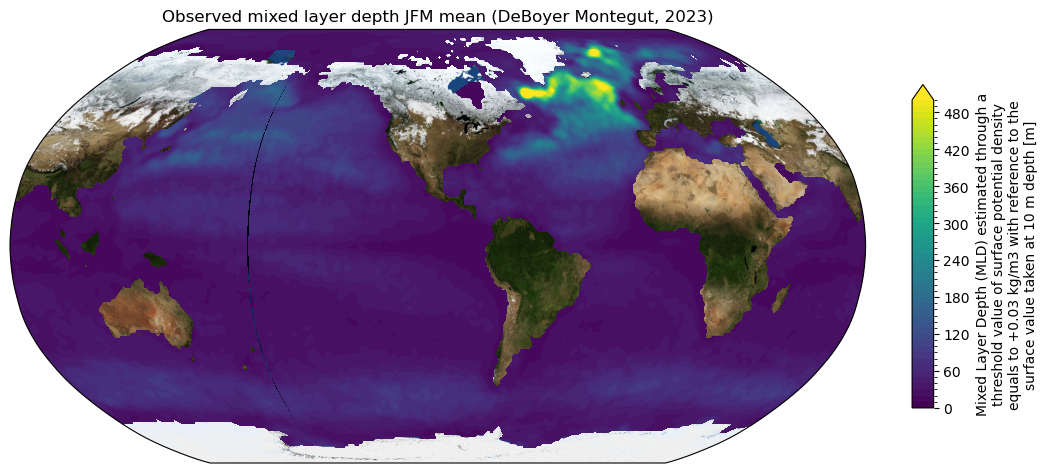

In [22]:
plot(MLDobs_JFM_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title=f"Observed mixed layer depth JFM mean (DeBoyer Montegut, 2023)"
    )
mkmd.savefig(plt.gcf(), "Mixed Layer Depth", "Observed ocean Mixed Layer Depth JFM.")

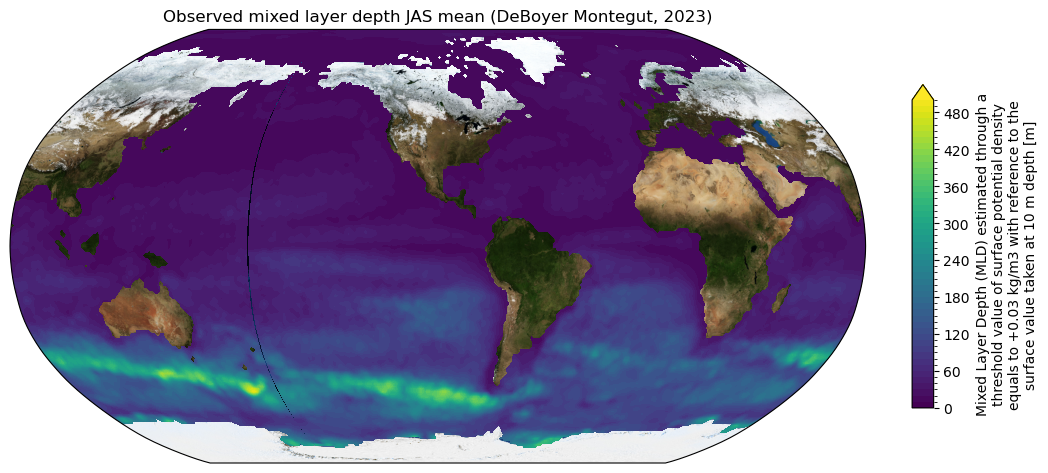

In [23]:
plot(MLDobs_JAS_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title=f"Observed mixed layer depth JAS mean (DeBoyer Montegut, 2023)"
    )
mkmd.savefig(plt.gcf(), "Mixed Layer Depth", "Observed ocean Mixed Layer Depth JAS.")

In [24]:
client.close()